<a href="https://colab.research.google.com/github/parika8ec-hub/DataScience_Project_BIA/blob/Labs/Lab15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-18-a8b03656365d>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


Accuracy: 0.78708303761533
Confusion Matrix:
 [[927 108]
 [192 182]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



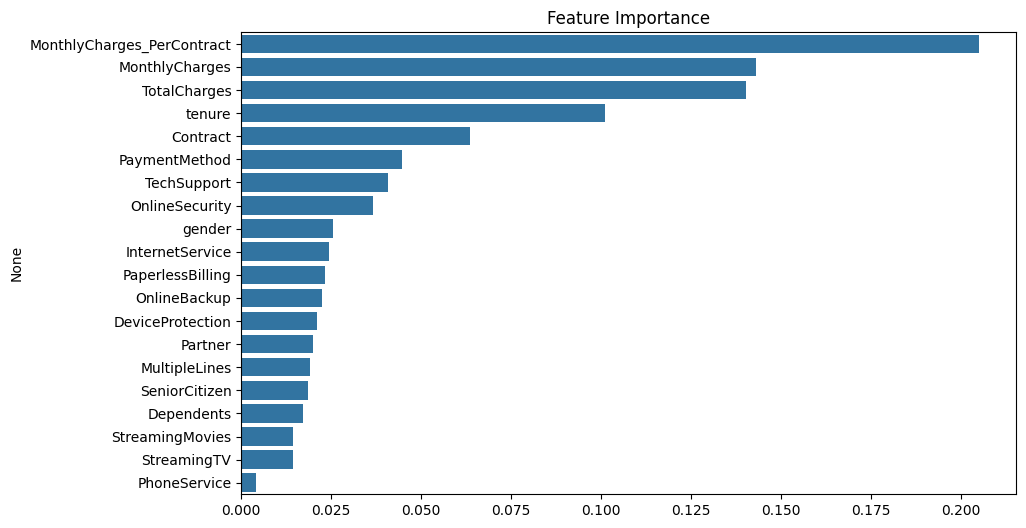

In [ ]:
# Task 1: Analyze the Use Case
# Use Case: Customer Churn Prediction in Telecommunications

# Task 2: ML Lifecycle for Churn Prediction

# Step 1: Data Collection and Loading
import pandas as pd
import numpy as np

# Load the dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'  # Corrected URL
data = pd.read_csv(url)

# Display data overview
# print(data.head())
# print(data.info())

# Step 2: Data Cleaning and Preprocessing
# Handle missing values
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# Step 4: Train-Test Split (Moved before encoding and feature engineering)
from sklearn.model_selection import train_test_split

# Split the dataset
# Handle potential NaNs in 'Churn' column before mapping
data['Churn'] = data['Churn'].fillna('No')  # Replace NaNs with 'No'
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})  # Use map to replace values

X = data.drop(['Churn', 'customerID'], axis=1)  # Drop 'customerID' here
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2 (Continued): Encoding categorical variables (After train-test split)
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
for col in X_train.select_dtypes(include=['object']).columns:  # Encode on X_train
    X_train[col] = label_enc.fit_transform(X_train[col])
    X_test[col] = label_enc.transform(X_test[col])  # Transform X_test using the same encoder


# Step 3: Feature Engineering (After train-test split)
from sklearn.preprocessing import MinMaxScaler

# Create new features
X_train['MonthlyCharges_PerContract'] = X_train['MonthlyCharges'] / (X_train['tenure'] + 1)
X_test['MonthlyCharges_PerContract'] = X_test['MonthlyCharges'] / (X_test['tenure'] + 1)  # Apply to X_test

# Scale numerical features
scaler = MinMaxScaler()
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'MonthlyCharges_PerContract']
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])  # Transform X_test


# Step 5: Model Training and Evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train a Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate Model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Feature Importance Analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize feature importance
importances = model.feature_importances_
features = X_train.columns  # Use X_train.columns

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]
importances = importances[indices]
features = features[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.show()